# Knowledge Distillation

> A good teacher does more than give the correct answer—they also explain their reasoning and correct mistakes as they happen. The relationship between a large model and a small model is similar: rather than letting the small model figure everything out on its own, let the large model "teach" it.
>
> This section covers three distillation methods: Logit-based (learning output distributions), Feature-based (learning intermediate representations), and On-Policy (the large model grades in real time), and walks through the complete pipeline from distilling a large model down to a small one.

In the LLM context, the Teacher is the more capable model (it can be a closed-source API, a large open-source model, or an enhanced version of the same model), and the Student is the target deployment model. The traditional approach is to have the Teacher write the standard answer, and have the Student learn from it.

But once the Student has memorized the Teacher's outputs, quality drops when it generates on its own. The reason is that the Student's training data differs from the data distribution it encounters during generation—this gap is called distribution shift.

The earliest and most classic method is Logit-based distillation—having the Student learn not just the answer, but also the Teacher's probability judgment for every token.

## 1. The Essence of Distillation

```
Plain SFT (Supervised Fine-Tuning):
  Teacher output: "Paris"
  Student learns: input "What is the capital of France?" -> output "Paris"
  Problem: only learned the answer, not the reasoning process

Distillation:
  Teacher output: probability for every token [Paris:0.9, London:0.05, Berlin:0.03, ...]
  Student learns: not only output "Paris", but also make the entire probability
                   distribution close to the Teacher's
  Benefit: Student learns the Teacher's "judgment"—knowing "Paris" is most likely,
           "London" is also plausible but lower probability
```

**Why is the probability distribution more valuable than the answer?**

When the Teacher says "Paris 90%, London 5%, Berlin 3%", it provides two extra pieces of information compared to just saying "Paris":
1. London and Berlin are also reasonable (just less correct)—this is called "dark knowledge"
2. The other hundreds of cities have near-zero probability—explicitly telling the Student which ones are wrong

This is the "soft target / dark knowledge" intuition emphasized by Hinton et al. in knowledge distillation. Reference: [Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531).

In [1]:
import numpy as np

# Hard labels vs. soft labels: compare using real probability distributions
print("=== Hard Labels vs. Soft Labels ===")
print()

cities = ["Paris", "London", "Berlin", "Rome", "Madrid", "Tokyo", "Beijing", "Sydney"]
teacher_logits = np.array([5.0, 2.0, 1.0, 0.5, 0.1, -3.0, -4.0, -5.0])

# Hard labels (SFT): one-hot, 1.0 only at the correct answer position
hard_labels = np.zeros(len(cities))
hard_labels[0] = 1.0

print("Question: What is the capital of France?")
print()
print("Hard labels (SFT):")
for city, prob in zip(cities[:5], hard_labels[:5]):
    bar = "\u2588" * int(prob * 40)
    print(f"  {city}: {prob:.1%} {bar}")
print("  Student only knows 'Paris is correct', everything else is zeroed out")
print()

# Soft labels (distillation): apply temperature T to soften logits, then softmax
temperature = 3.0
scaled_logits = teacher_logits / temperature
soft_labels = np.exp(scaled_logits) / np.exp(scaled_logits).sum()

print(f"Soft labels (distillation, T={temperature:.0f}):")
for city, prob in zip(cities, soft_labels):
    bar = "\u2588" * int(prob * 40)
    print(f"  {city}: {prob:.1%} {bar}")
print("  Student learns:")
print("    1. Paris is most correct (high probability)")
print("    2. London, Berlin are also European capitals (similarity knowledge)")
print("    3. Tokyo, Beijing probability ~ 0 (explicitly excluded)")
print()

# Quantify the information difference: information entropy
hard_entropy = -np.sum(hard_labels * np.log(hard_labels + 1e-10))
soft_entropy = -np.sum(soft_labels * np.log(soft_labels + 1e-10))
print(f"Hard label entropy: {hard_entropy:.2f} bits")
print(f"Soft label entropy: {soft_entropy:.2f} bits")
print(f"Soft labels carry about {soft_entropy:.2f} bits of extra information, hard labels near 0")


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Paris: 100.0% ████████████████████████████████████████London: 0.0%Berlin: 0.0%Rome: 0.0%Madrid: 0.0%Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Paris: 45.4% ██████████████████London: 16.7% ██████Berlin: 12.0% ████Rome: 10.1% ████Madrid: 8.9% ███Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.    1. Read the values printed above and connect them to the concept in this cell.    2. Read the values printed above an

## 2. Method 1: Logit Distillation (The Classic Approach)

Make the Student's output probability distribution approximate the Teacher's output probability distribution.

**Loss formula**:

$$L = (1-\alpha) \cdot L_{CE}(S, y) + \alpha \cdot T^2 \cdot L_{KL}(S_T, T_T)$$

Where:
- $L_{CE}$: Cross-entropy between Student and the correct answer (ensures basic correctness)
- $L_{KL}$: KL divergence between Student and Teacher probability distributions (learns dark knowledge)
- $T$: Temperature parameter—the larger it is, the "softer" the Teacher's distribution (dark knowledge becomes more visible)
- $\alpha$: Weight balancing the two losses

**Effect of temperature T**:
```
T=1:  [0.90, 0.05, 0.03, 0.02]  <- Very sharp, dark knowledge not visible
T=5:  [0.40, 0.25, 0.20, 0.15]  <- Softened, dark knowledge emerges
T=20: [0.28, 0.26, 0.24, 0.22]  <- Too soft, becomes nearly uniform
```

T too large -> all tokens have similar probability -> no information
T too small -> no different from hard labels -> no dark knowledge
T=3~10 is a common experimental starting point, not a fixed rule; the best T depends on the task, model, and loss weight, and should be tuned on a validation set.

In [2]:
import numpy as np

# Effect of temperature T on soft labels
print("=== Effect of Temperature T on Soft Labels ===")
print()

logits = np.array([5.0, 2.0, 1.0, 0.5, 0.1, 0.01, 0.001, 0.0001])
labels = ["Paris", "London", "Berlin", "Rome", "Madrid", "Vienna", "Prague", "Warsaw"]

for T in [1, 3, 10, 20]:
    scaled = logits / T
    probs = np.exp(scaled) / np.exp(scaled).sum()

    print(f"T={T:2d}: ", end="")
    for i in range(5):
        bar = "\u2588" * int(probs[i] * 50)
        print(f"{labels[i]}:{probs[i]:.3f} {bar}  ", end="")
    print()

print()
print("T=1:  Almost all Paris -> dark knowledge is hidden")
print("T=3:  London, Berlin emerge -> dark knowledge starts to appear")
print("T=10: Distribution more uniform -> dark knowledge is rich but the correct-answer signal weakens")
print("T=20: Nearly uniform -> too little information")


Read the values printed above and connect them to the concept in this cell.
T= 1: Paris:0.903 █████████████████████████████████████████████ London:0.045 ██ Berlin:0.017 Rome:0.010 Madrid:0.007T= 3: Paris:0.382 ███████████████████ London:0.141 ███████ Berlin:0.101 █████ Rome:0.085 ████ Madrid:0.075 ███T=10: Paris:0.182 █████████ London:0.135 ██████ Berlin:0.122 ██████ Rome:0.116 █████ Madrid:0.112 █████T=20: Paris:0.152 ███████ London:0.130 ██████ Berlin:0.124 ██████ Rome:0.121 ██████ Madrid:0.119 █████
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 3. Method 2: Data Distillation (The Most Practical)

When doing full-vocab logit distillation, the Student and Teacher ideally share a tokenizer, or have a reliable cross-tokenizer alignment; closed-source APIs usually do not expose full logits, so in the LLM setting, data distillation (or using only top-k / sampled-token approximate signals) is far more common.

**Data distillation bypasses this problem**: have the Teacher generate training data, and train the Student on this data with SFT.

```
Step 1: Collect prompts (from your business scenario)
  ["Write a poem about spring", "Explain quantum mechanics", "Translate: Hello -> Chinese", ...]

Step 2: Teacher generates high-quality answers for each prompt
  GPT-4: "Spring has arrived, all things come alive..."
  GPT-4: "Quantum mechanics is the study of subatomic particles..."

Step 3: Train Student on (prompt, teacher_answer) pairs
  Student does standard SFT, learning to imitate the Teacher's output style and quality
```

**Advantage**: No requirement for matching vocabularies; any Teacher can teach any Student.
**Disadvantage**: Only learns "what the answer looks like", not "the dark knowledge in the probability distribution".

**Advanced data distillation techniques**:
- **Multi-turn dialogue distillation**: Teacher generates multi-turn conversations, Student learns conversational rhythm
- **CoT distillation**: Teacher generates answers with reasoning steps, Student learns to reason
- **Rejection sampling**: Teacher generates multiple answers, only the best ones are kept for Student training

In [3]:
# Data distillation pipeline simulation: Teacher generates training data, Student does SFT on it
print("=== Data Distillation Pipeline ===")
print()

prompts = [
    "Explain what machine learning is",
    "Write a five-character poem about autumn",
    "Difference between list and tuple in Python",
]

# Simulate Teacher (GPT-4) answers
teacher_responses = [
    "Machine learning is a branch of AI that enables computers to learn patterns from data without explicit programming.",
    "Autumn wind sweeps fallen leaves, frost kills hundred flowers. Sitting alone by cold window, wondering if your clothes are warm.",
    "list is mutable (can add, remove, modify), tuple is immutable (cannot change after creation). list uses [], tuple uses ().",
]

print("Step 1: Collect prompts, Step 2: Teacher generates answers")
for i, (prompt, response) in enumerate(zip(prompts, teacher_responses)):
    print(f"\n--- Sample {i+1} ---")
    print(f"User: {prompt}")
    print(f"Assistant: {response}")

print()
print(f"Step 3: Use the {len(prompts)} (prompt, teacher_answer) pairs as SFT training data")
print("Scale: a few thousand samples is enough to validate the concept; production-quality results usually need more high-quality, diverse samples")
print("The exact amount depends on task breadth, teacher quality, and the student base model's capability—decide whether to keep expanding based on the validation set")


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Explanation: the printed values show the main mechanism in this step.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Exercise passed: you have 

## 4. Method 3: Feature Distillation (Advanced)

Not only learn the output distribution, but also learn intermediate layer representations.

```
Teacher (GPT-4, 96 layers):
  Layer 1 -> Layer 2 -> ... -> Layer 48 -> ... -> Layer 96 -> Output
                                     ^
Student (7B, 32 layers):             |  Make Student's Layer 16 output
  Layer 1 -> Layer 2 -> ... -> Layer 16 -> ... -> Layer 32 -> Output  approximate Teacher's Layer 48
```

**Why is this effective?** Intermediate layers contain information about "how to understand this sentence", which is richer than the final output.

**Why is it rarely used?**
- Requires access to the Teacher's internal representations (not possible with closed-source models)
- Teacher and Student have different dimensions, requiring projection matrices for alignment
- High computational cost and memory consumption

In the closed-source-teacher + open-source-student LLM setting, data distillation is the easiest to land; feature distillation is used more often in white-box settings where teacher hidden states are accessible, and similar ideas appear in vision models and small language models.

## 5. Hands-on: Distilling a 7B Model

The previous sections covered the principles of three distillation methods. Now let's string them together into a complete distillation pipeline. The entire process has four steps:

1. **Prepare training data**: Collect a batch of high-quality prompts covering the target domain—math reasoning, code generation, or general conversation
2. **Teacher generation**: Use the strong Teacher model to generate an answer for each prompt; the specific model and price change over time, saved as (prompt, teacher_answer) pairs
3. **Student training**: If teacher logits are available, you can do KL-based logit distillation; if only text answers are available, do data distillation with SFT
4. **Evaluation and comparison**: Compare the Student's scores before and after distillation using evaluation benchmarks

Below, each step comes with executable code. Even without a real GPT-4 API key, you can use a local MiniGPT to simulate the Teacher and Student roles and run through the complete pipeline.

Six steps of the distillation pipeline:

1. **Choose a base model**: Qwen2.5-7B / Llama-3-8B / Mistral-7B, etc. The base model itself must have some baseline capability; usually pick an Instruct version (already knows how to follow instructions).
2. **Collect prompts**: Business data, open-source datasets (OpenHermes, ShareGPT, WildChat), or use another LLM to generate diverse prompts. First validate data quality at a small scale, then expand based on validation-set gains.
3. **Teacher generates answers**: Use the GPT-4 API to generate an answer for each prompt, set the system prompt to define the Teacher role, temperature=0.7 to preserve some diversity. Cost is estimated from that day's API price, input/output tokens, retry rate, and filter rate.
4. **Data cleaning**: Remove answers that are too short (<20 tokens), contain refusals like "As an AI", have malformed formatting, or are duplicates with similarity > 0.9.
5. **SFT training**: Use tools like LLaMA-Factory, Axolotl, or Firefly, with ChatML or ShareGPT format; a common starting point is lr=2e-5, epochs=3, batch_size=128. Hardware cost depends on model size, LoRA/full-parameter, sequence length, and optimizer strategy.
6. **Evaluation**: Run standard benchmarks with lm-eval, do human evaluation on business data, and compare the gap between Student and Teacher.

## 6. Distillation vs. OPD Comparison

| Dimension | Data Distillation | OPD (On-Policy Distillation) |
|:---|:---|:---|
| **When Teacher participates** | Before training (generates data) | During training (scores in real time) |
| **Student training data** | Standard answers written by Teacher | Answers written by Student itself |
| **Engineering complexity** | Low (just SFT) | High (requires rollout + real-time Teacher) |
| **Exposure Bias** | May exist (training prefixes mostly from teacher/dataset) | Mitigated (trained on the student's current prefix), but not guaranteed to be fully eliminated |
| **Vocabulary requirement** | None for text-level data distillation | Logit/token-level OPD requires same tokenizer or cross-tokenizer alignment; black-box feedback can bypass some constraints |
| **Cost** | Low (Teacher runs only once) | High (Teacher runs every training iteration) |
| **Best for** | Quick prototyping, limited budget | Pursuing maximum performance, has engineering team |

**Recommendation**: Start with data distillation for a quick first version; if the results are good enough, ship it. If results are insufficient, then consider OPD.

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

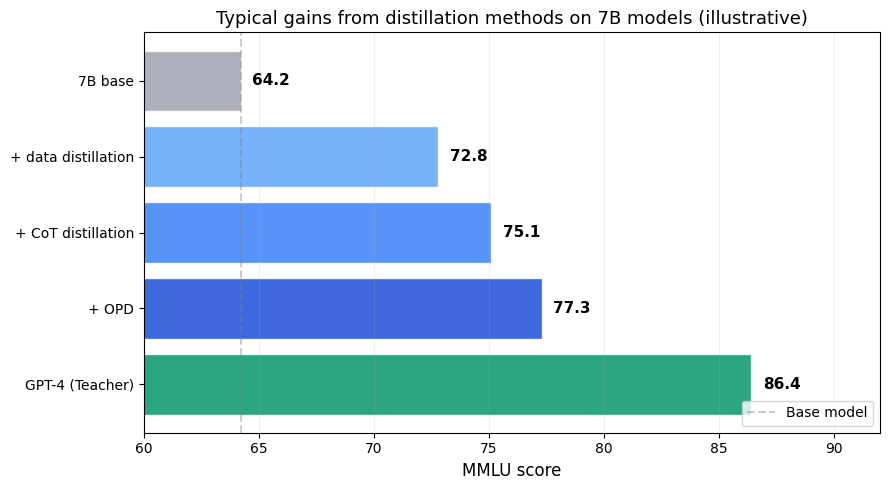

In [4]:
# Typical effectiveness comparison of distillation methods (order-of-magnitude figures based on public tech reports, illustrative only)
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

# Example scores: typical magnitude of 7B model MMLU scores from public reports
data = [
    ("7B base", 64.2, "#9CA3AF"),
    ("+ data distillation", 72.8, "#60A5FA"),
    ("+ CoT distillation", 75.1, "#3B82F6"),
    ("+ OPD", 77.3, "#1D4ED8"),
    ("GPT-4 (Teacher)", 86.4, "#059669"),
]
names = [d[0] for d in data]
scores = [d[1] for d in data]
colors = [d[2] for d in data]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names, scores, color=colors, alpha=0.85, edgecolor="white")
for bar, score in zip(bars, scores):
    ax.text(score + 0.5, bar.get_y() + bar.get_height()/2, f"{score:.1f}",
            va="center", fontsize=11, fontweight="bold")

ax.axvline(64.2, color="gray", linestyle="--", alpha=0.4, label="base starting point")
ax.set_xlabel("MMLU score", fontsize=12)
ax.set_title("Typical improvement of distillation methods on a 7B model (illustrative magnitude)", fontsize=13)
ax.set_xlim(60, 92)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print("Illustrative magnitude: data distillation usually improves 5-10 points, CoT distillation adds another 1-3 points, OPD has diminishing returns.")
print("The actual gain depends on teacher choice, data quality, training hyperparameters, and evaluation setup.")


## 7. Common Questions About Distillation

| Question | Answer |
|:---|:---|
| **Can the Student surpass the Teacher?** | The Teacher should not be treated as an absolute ceiling. The Student may surpass a particular teacher on a specific benchmark because it is better suited to that task, has cleaner data, uses stronger decoding/tools, or had additional training; but it usually cannot fully replicate the teacher's overall capability. |
| **What does distillation lose?** | Creativity, long-tail knowledge, complex reasoning—these are the hardest parts of the Teacher's "dark knowledge" to distill |
| **How much data is needed?** | There is no fixed minimum. First validate data quality and the training pipeline at a small scale, then expand based on validation-set gains; data quality, coverage, and deduplication are usually more important than sheer quantity. |
| **What if Teacher and Student vocabularies differ?** | Use data distillation (Method 2), which requires no vocabulary matching |
| **Is RLHF still needed after distillation?** | Depends on the scenario. Distillation inherits some of the teacher's style and safety behavior, but cannot guarantee full alignment; you still need safety evaluation, refusal boundaries, and business-data validation. |
| **Is multi-Teacher distillation feasible?** | Yes. Multiple teachers can complement each other by task, but you need to handle style conflicts, licensing/data policy, and quality filtering; "stronger overall capability" must be verified by evaluation. |

## Summary

- [ ] **Essence of distillation**: Learn the Teacher's probability distribution (dark knowledge), not just the standard answer
- [ ] **Logit distillation**: Make the Student's output distribution approximate the Teacher's; requires matching vocabularies
- [ ] **Data distillation**: Teacher generates training data, Student does SFT; the easiest to land in practice
- [ ] **Feature distillation**: Learn intermediate layer representations; suited for white-box teachers; effectiveness depends on layer alignment and the task
- [ ] **Hands-on pipeline**: Choose base model -> collect prompts -> Teacher generates -> clean -> SFT -> evaluate
- [ ] **Distillation vs. OPD**: Data distillation is easy to land; OPD may fit the student's real generation distribution better but costs more and is more complex
- [ ] **CoT distillation**: Have the Teacher generate answers with reasoning steps, so the Student learns to reason

**One-sentence summary**: Distillation = let the large model be the teacher, the small model be the student. The easiest method to land is data distillation: have a strong teacher generate high-quality samples, and the small model learns through SFT; sample size, teacher choice, and cost all need to be re-estimated per project.

## Exercises

> You can ask AI for help explaining ideas, breaking down steps, and checking direction, but it is not recommended to let AI "just do the whole problem for you."

**Exercise 1: Effect of temperature on soft labels**

In knowledge distillation, the temperature $T$ is used to soften the Teacher's output distribution: $p_i = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$. Given the Teacher's logits for three tokens: $[4.0, 2.0, 1.0]$. Compute the probability distribution for $T=1$ and $T=5$ respectively.

<details><summary>Hint</summary>At $T=1$ the distribution is sharp (probability concentrates on the maximum), at $T=5$ the distribution is flatter (dark knowledge is more visible).</details>

In [5]:
# Exercise 1: Effect of temperature on soft labels
import math

logits = [4.0, 2.0, 1.0]


def softmax_with_temp(logits, T):
    exps = [math.exp(l / T) for l in logits]
    total = sum(exps)
    return [e / total for e in exps]


# TODO: compute the probability distribution at T=1
probs_T1 = None  # compute here

# TODO: compute the probability distribution at T=5
probs_T5 = None  # compute here

assert probs_T1 is not None, "Please compute the probabilities for T=1 first"
assert probs_T5 is not None, "Please compute the probabilities for T=5 first"

expected_T1 = softmax_with_temp(logits, 1)
expected_T5 = softmax_with_temp(logits, 5)

for i, (p, e) in enumerate(zip(probs_T1, expected_T1)):
    assert abs(p - e) < 0.01, f"At T=1, p[{i}] should be {e:.4f}"

for i, (p, e) in enumerate(zip(probs_T5, expected_T5)):
    assert abs(p - e) < 0.01, f"At T=5, p[{i}] should be {e:.4f}"

dk_T1 = probs_T1[1] / probs_T1[2]
dk_T5 = probs_T5[1] / probs_T5[2]

print("Exercise 1 passed:")
print(f"   T=1: {probs_T1} -> probability concentrates on the maximum")
print(f"   T=5: {probs_T5} -> distribution more uniform, dark knowledge more visible")
print(f"   dark knowledge ratio (second-largest / smallest): T=1={dk_T1:.2f}, T=5={dk_T5:.2f}")
print("   The higher the temperature, the clearer the probability differences among non-correct answers—this is dark knowledge.")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Exercise 2: KL divergence by hand**

KL divergence measures the difference between two distributions: $D_{KL}(P \| Q) = \sum_i P_i \log \frac{P_i}{Q_i}$. Given Teacher distribution $P = [0.7, 0.2, 0.1]$ and Student distribution $Q = [0.5, 0.3, 0.2]$. Compute the KL divergence by hand.

<details><summary>Hint</summary>$D_{KL} = 0.7 \times \log(0.7/0.5) + 0.2 \times \log(0.2/0.3) + 0.1 \times \log(0.1/0.2)$.</details>

In [6]:
# Exercise 2: KL divergence by hand
import math

P = [0.7, 0.2, 0.1]
Q = [0.5, 0.3, 0.2]

# TODO: compute KL divergence D_KL(P || Q)
kl_div = None  # compute here

assert kl_div is not None, "Please compute the KL divergence first"

expected = sum(p * math.log(p / q) for p, q in zip(P, Q))
assert abs(kl_div - expected) < 0.01, f"KL divergence should be {expected:.4f}, you got {kl_div:.4f}"

print("Exercise 2 passed:")
print(f"   Teacher: {P}")
print(f"   Student: {Q}")
print(f"   KL(P||Q) = {kl_div:.4f}")
print("   KL divergence >= 0, and equals 0 if and only if the two distributions are identical.")
print("   The goal of distillation is to minimize the KL divergence between Student and Teacher.")


Exercise passed: you have understood this step.   Teacher: [0.7, 0.2, 0.1]
   Student: [0.5, 0.3, 0.2]
   KL(P||Q) = 0.0851
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Exercise 3: Comparing three distillation methods**

| Method | Requires Teacher online | Training data source | Engineering complexity |
|:---|:---|:---|:---|
| Logit distillation | Yes | Original dataset | Medium |
| Data distillation | No (offline) | Data generated by Teacher | Low |
| Feature distillation | Yes | Original dataset | High |

Scenario: A team has a 70B Teacher and a 7B Student, with limited training resources (4 A100 GPUs). Which distillation method should they choose?

<details><summary>Hint</summary>With limited resources, prefer the option with low engineering complexity that does not require real-time Teacher participation.</details>

In [7]:
# Exercise 3: Comparing three distillation methods
answer = "fill your answer here"
# A) Logit distillation
# B) Data distillation
# C) Feature distillation

assert not answer.startswith("fill your answer here"), "Please fill in your answer first"
assert answer in "ABC", "Please fill in one of A/B/C"

if answer == "B":
    print("Exercise 3 passed:")
    print("   Under limited resources, data distillation is the most pragmatic choice:")
    print("   1. The Teacher generates data offline, no need to call it in real time during training")
    print("   2. The Student side is equivalent to SFT, simple to implement")
    print("   3. Teacher inference runs only once; subsequent training does not need the Teacher")
    print("   4. 4 A100s are enough to complete SFT training of a 7B model")
else:
    reasons = {
        "A": "Logit distillation requires real-time Teacher participation, called at every step, which is more expensive.",
        "C": "Feature distillation requires access to intermediate-layer outputs, with the highest engineering complexity.",
    }
    print(f"You chose {answer}. {reasons.get(answer, '')}")
    print("Hint: with limited resources -> pick the simplest option that does not require real-time Teacher participation.")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.   1. Read the values printed above and connect them to the concept in this cell.   2. Read the values printed above and connect them to the concept in this cell.   3. Read the values printed above and connect them to the concept in this cell.   4. Read the values printed above and connect them to the concept in this cell.